In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
# %pip install tiktoken
import tiktoken
import numpy as np

In [72]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#Building the Dataset
f = open('tiny-shakespeare.txt')
text = f.read()

print("Length of the Dataset:", len(text), "\n")
print(text[:100]) #first 100 characters

chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f'\nVocabulary Size: {vocab_size}')
print('-'.join(chars))

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i: ch for i,ch in enumerate(chars)}

encode = lambda s: [stoi[ch] for ch in s]
decode = lambda ary: ''.join([itos[i] for i in ary])
raw_text = "ben Onur"
print(f'\nRaw Text:  {raw_text}')
token_list = encode(raw_text)
print("Token List:", token_list)
decoded = decode(token_list)
print("decoded:", decoded)

# Compare with OpenAI byte-pair encoding (BPE)
# Tiktoken shows that there is a trade-off between the length of the encoding and the amount of tokens.
# We can have short sequences of tokens with very large vocabulary, or we can just as well have long sequences of tokens with a small vocabulary.
# The BPE approach is widely used for NLP tasks
enc = tiktoken.get_encoding('gpt2')

token_list_BPE = enc.encode(raw_text)
print("token_list_BPE:", token_list_BPE) # BPE returns fewer tokens than the character encoding
print(enc.decode(enc.encode(raw_text)))

print(enc.n_vocab) # total amount of tokens in the vocabulary


Length of the Dataset: 1115394 

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You

Vocabulary Size: 65

- -!-$-&-'-,---.-3-:-;-?-A-B-C-D-E-F-G-H-I-J-K-L-M-N-O-P-Q-R-S-T-U-V-W-X-Y-Z-a-b-c-d-e-f-g-h-i-j-k-l-m-n-o-p-q-r-s-t-u-v-w-x-y-z

Raw Text:  ben Onur
Token List: [40, 43, 52, 1, 27, 52, 59, 56]
decoded: ben Onur
token_list_BPE: [11722, 1550, 333]
ben Onur
50257


In [73]:
# Encode the text into a tensor of integers
encoded_data = encode(text)
data = torch.tensor(encoded_data, dtype = torch.long)
print(f'Total size: {data.shape} elements of type {data.dtype}')
print('First 10 tokens from the dataset:', data[:10])

n = int(0.9 * len(data))

train_data = data[:n]
val_data = data[n:]

torch.manual_seed(1337)
#mini-batching.
def get_batch(encoded_data, block_size, batch_size ):
    ix = torch.randint(0, len(encoded_data) - block_size, (batch_size, ))

    X = torch.stack([encoded_data[i:i+block_size] for i in ix], dim=0)
    Y = torch.stack([encoded_data[i+1:i + block_size + 1] for i in ix], dim=0)

    return X,Y      

batch_size = 32 # = 64 how many independent sequences will we process in parallel?
block_size = 8 # = 256 what is the maximum context length for predictions?
learning_rate = 3e-4 #1e-3  #1e-2

# "num_heads × head_size" must be equal to "C (n_embd)" in order the multi-head attention work
n_embd = 384 # = 384            # (n_head * batch_size)
n_head = 6                      # arbitrary
head_size = n_embd // n_head    # (n_embd/n_head): convention 

n_layer = 6 
dropout = 0.2

xb, yb = get_batch(train_data, block_size, batch_size)
# Print the shape of the batch and the actual data
print('inputs shape: ', xb.shape)
print(xb,'\n')
print('targets shape: ', yb.shape)
print(yb, '\n')

for b in range(batch_size):# batch dimension, number of sequences in the batch (batch_size)
    for ci in range(block_size):# time dimension, number of tokens in the sequence  (block_size)
        input = xb[b, :ci+1]# context means prompt, taking the first t+1 tokens from the b-th sequence in the batch
        output = yb[b, ci] # we take the t-th token from the b-th sequence in the batch for the target (the token we want to predict)
        print(f'for Input {input}, predict the output {output}') # This context <-> target pair is what we feed to the model, it's variable in length
        


Total size: torch.Size([1115394]) elements of type torch.int64
First 10 tokens from the dataset: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47])
inputs shape:  torch.Size([32, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54],
        [57, 43, 60, 43, 52,  1, 63, 43],
        [60, 43, 42,  8,  0, 25, 63,  1],
        [56, 42,  5, 57,  1, 57, 39, 49],
        [43, 57, 58, 63,  6,  1, 58, 46],
        [43,  1, 51, 39, 63,  1, 40, 43],
        [58, 46, 43,  1, 43, 39, 56, 57],
        [39, 58, 47, 53, 52, 12,  1, 37],
        [53, 56, 43,  1, 21,  1, 41, 39],
        [50, 39, 52, 63,  1, 47, 58, 57],
        [56, 53, 63,  1, 42, 47, 42,  1],
        [39, 51,  1, 39, 44, 56, 39, 47],
        [17, 24, 21, 38, 13, 14, 17, 32],
        [ 1, 39, 52, 42,  1, 45, 43, 50],
        [ 1, 58, 46, 39, 58,  1, 42, 53],
        [ 1, 61, 53, 59, 50, 42,  1, 21],
        [59, 57, 40, 

In [ ]:
# Embedding Layer
# sub-batching using mini-batches
# yb[i, j] is the next token after xb[i, j]

torch.manual_seed(1337)
every_train_losses = []
every_val_losses = []
train_losses_eval_interval  = []
eval_iters = 200
max_iters = 10000
eval_interval = 500

#inheritance from nn.Module
class BiagramLM(nn.Module):
    
    def __init__(self, vocab_size, block_size, n_embd, batch_size = 32):
        super().__init__()
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.batch_size = batch_size
        self.n_embd = n_embd
        self.context_needed = 1 # = self.block_size       # a bigram reads ONLY the last token for this example, it will be context_needed = block_size when transformers come into play
        # Embedding the vocabulary
        # Every one of the vocab_size tokens is represented by a vector of size vocab_size
        # With embedding_dim = vocab_size, the "embedding" isn't an embedding at all — it's a "65 × n_embd" bigram score matrix
        self.token_embedding_table  = nn.Embedding(num_embeddings=self.vocab_size, embedding_dim=self.n_embd) # 65 unique n_embd-dim vectors (self.n_embd = vocab_size will be chaged for self attention)
        self.position_embedding_table = nn.Embedding(num_embeddings=self.block_size, embedding_dim=self.n_embd) # new positional embedding table
        self.lm_head = nn.Linear(in_features=self.n_embd, out_features= self.vocab_size) # intermediary linear layer to go from embeddings to the logits so that we can do the weighted aggregation of the past tokens with size (n_embd, n_embd)
        print("Token Embedding Shape:", self.vocab_size, "X", self.n_embd)
        print("Position Embedding Shape:", self.block_size, "X", self.n_embd)
        print("Linear Head From Embeddings to Logits Shape:", self.n_embd, "X", self.vocab_size)

    def forward(self, idx, targets=None): 
        # idx is of shape (batch_size, block_size)
        # targets is of shape (batch_size, block_size)
        # Embed the input indices, shape is now (batch_size, block_size, embedding_dim=n_embd) (B, T, C)     
        
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T)) #(T, C)
        # add the positional tokens
        x = tok_emb + pos_emb
        logits = self.lm_head(x)

        if targets is None: # don't compute loss if targets not given (used for generation)
            loss = None
        else:
            B, T, C = logits.shape # B = batch_size, T = block_size, C = embedding_dim = vocab_size
            logits = logits.view(B*T, C) # Flatten B and T dimensions
            targets = targets.view(B*T) # # Flatten B and T dimensions (targets contains the next token's index for each input sequence in the batch)
            loss = F.cross_entropy(logits, targets) # F.cross_entropy inputs shape (B, C, T) - Calculating cross entropy loss across all tokens in the batch (using targets to plug out the correct token for each input sequence)
        return logits, loss    

    # Generate new tokens based on respective last token of a sequence
    def generate(self, idx, max_new_tokens):
        # Repeated over n times, it will:
        #   forward pass through the model with tokens xb to get logits
        #   disregard everything but the last token of xb
        #   calculate the probability of each possible token in the vocabulary to be the token after this last xb token; this is done with F.softmax
        #   sample a token from the probability distribution with torch.multinomial, this returns an index of the token that we can use to look up the token itself in the vocabulary if we wanted
        #   append the sampled token to the tokens xb
        #   repeat
        for i in range(max_new_tokens):
            # Forward pass (this is the forward function) with the current sequence of characters idx, results in (B, T, C)
            idx_cond = idx[:, -self.context_needed:]  # never exceed the context window (but we are currently only using the last token not the block)

            logits, _ = self.forward(idx_cond) #self(idx_cond) (logits = embed(idx))
            # Focus on the last token from the logits (B, T, C) -> (B, C) (C = last token's embedding for every batch)
            logits_last_token = logits[:, -1, :]

            # Calculate the probability distribution for the next token based on this last token, results in (B, C)
            probs = F.softmax(logits_last_token, dim=1)
            # Sample the next token (B, 1), the token with the highest probability is sampled most likely
            idx_next = torch.multinomial(probs, num_samples=1) #Yes — idx_next is a token id, which is the row index in the embedding look-up table
            # Add the new token to the sequence (B, T+1) for the next iteration
            idx = torch.cat((idx, idx_next), dim=1)

            if i % 7 == 0:
                print("Input idx:", i+1, idx_cond)
                print("Logits Last Token:", logits_last_token, "Shape:", logits_last_token.shape, "idxShape:", idx.shape, "idx_next:", idx_next, "logits Shape:", logits.shape)
        return idx

    def fit(self):
        # Create a PyTorch Optimizer
        # Instantiate AdamW optimizer with the model parameters (weights) 
        # and a learning rate of 0.001 (often used value for *small* networks)
        opt = torch.optim.AdamW(self.parameters(), lr=1e-3)       

        # Train for max_iters 
        for iter in range(max_iters):
            xb, yb = get_batch(train_data, self.block_size, self.batch_size) # Sample a batch of data
            logits, loss = self.forward(xb, yb)                # Forward pass, calculate the loss
            if loss is not None:
                loss.backward()                         # Backprop with PyTorch's autograd 
                                                    # (effectively just updating the logits/the embedding vectors)
            opt.step()                              # Update the weights
            opt.zero_grad(set_to_none=True)         # Reset gradients - Set the gradients to zero

            if loss is not None:
                every_train_losses.append(loss.item()) 

                # Print the loss every 100 iter
                if iter % eval_interval == 0:
                    current_loss = self.evaulate_loss()
                    train_losses_eval_interval.append(current_loss["train"].item())                
                    print(f'Iter {iter:4d} | Current Mean Train Loss {current_loss["train"]:6.4f} | Mean Val Loss {current_loss["val"]:6.4f} for every {eval_interval}')

    @torch.no_grad() # Disable gradient calculation for this function
    def evaulate_loss(self):
        out = {}
        was_training = self.training
        self.eval() # Set model to evaluation mode

        for split in ['train', 'val']:
            temp_losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                if split == 'train':
                    X, Y = get_batch(train_data, self.block_size, self.batch_size)
                if split == 'val':
                    X, Y = get_batch(val_data, self.block_size, self.batch_size)

                _, loss = self.forward(X, Y)

                if loss is not None:
                    temp_losses[k] = loss.item()
                    every_val_losses.append(loss.item())

            out[split] = temp_losses.mean() # Set model back to training mode
        self.train(was_training)
        return out              

#Single Self-Attention Head
class Head(nn.Module):
    def __init__(self, head_size, dropout=0.2, masked=True): #head_size is the output number of the Attention
        super().__init__()
        self.masked = masked
        self.key = nn.Linear(in_features=n_embd, out_features=head_size, bias=False) 
        self.query = nn.Linear(in_features=n_embd, out_features=head_size, bias=False) 
        self.value = nn.Linear(in_features=n_embd, out_features=head_size, bias=False)
        self.dropout = nn.Dropout(dropout)

        if self.masked is True:
            self.tril: torch.Tensor
            self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size))) #to be used for masked attention

    def forward(self, x, ):
        B, T, C = x.shape # Hs: head_size T:block_size C:n_embd
        k = self.key(x)   # X[B, T, C] x W_key[C, Hs] = [B, T, Hs]
        q = self.query(x) # X[B, T, C] x W_query[C, Hs] = [B, T, Hs]
        v = self.value(x) # X[B, T, C] x W_value[C, Hs] = [B, T, Hs]

        dim = k.shape[-1] # dimension of the last dim = head_size
        kt = k.transpose(-2, -1) # transpose the last two dimensions
        inv_sqrt_dim = (dim ** -0.5) # 1/sqrt(d)
        attention_scores = (q @ kt) * inv_sqrt_dim # q[B, T, Hs] x k.T[B, Hs, T] = [B, T, T]

        if self.masked is True:
            attention_scores = attention_scores.masked_fill(self.tril[:T, :T] == 0, float('-inf')) #fill zeros with infinitive self.tril[:T, :T] --> without [:T, :T], generation with a 3-token prompt would crash on a shape mismatch

        # create attention map of probabilities [B, T, T]
        attention_map = F.softmax(attention_scores, dim=-1) #as we want the attention map gives sum of "1.0" row-wise, the last dim should be given "dim = -1"

        # apply drop-out
        # Standard practice is after the softmax, before the @ v — it randomly severs individual token-to-token connections, which is what you want to regularise. 
        # Dropping on the scores before softmax would be wrong (the -inf mask and renormalisation would fight it), and dropping on v is a different, weaker idea       
        attention_map = self.dropout(attention_map)

        # The Output
        z = attention_map @ v # attention_map[B, T, T] x v[B, T, Hs] = [B, T, Hs]
        return z

# Multi-Head Attention from single heads module
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """
    def __init__(self, num_heads, head_size, dropout=0.2):
         super().__init__()
         assert num_heads * head_size == n_embd, \
            f"num_heads*head_size ({num_heads}*{head_size}={num_heads*head_size}) must equal n_embd ({n_embd})"
         # h = num_heads
         # Hs = head_size
         # dk = dv = d_model / h
         # MultiHead(Q, K, V) = Concat(head1 ... headh) x W_multihead
         self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])   # num_heads x Head[B, T, Hs]    
         self.proj = nn.Linear(num_heads * head_size, n_embd) # [num_heads*head_size = C, C]
         self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # [h(x) for h in self.heads] runs the heads sequentially in Python. 
        # Real implementations do one fused Linear(n_embd, 3*n_embd) and reshape to (B, num_heads, T, head_size), so all heads are one batched matmul
        out = torch.cat([h(x) for h in self.heads], dim=-1) #h(x) = Head[B, T, Hs], Cat on the last dimension: Head[B, T, num_heads × head_size]
        out = self.proj(out) # [B, T, num_heads × head_size = C] x proj[(B), num_heads * head_size = C, C] ---> !!! then num_heads × head_size must be equal to C (n_embd)) = [B, T, C]
        out = self.dropout(out)
        return out







In [11]:
tril_buf = torch.tril(torch.ones(block_size, block_size))
a = F.softmax(tril_buf, dim=1)
tril_buf, a

(tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.]]),
 tensor([[0.2797, 0.1029, 0.1029, 0.1029, 0.1029, 0.1029, 0.1029, 0.1029],
         [0.2377, 0.2377, 0.0874, 0.0874, 0.0874, 0.0874, 0.0874, 0.0874],
         [0.2066, 0.2066, 0.2066, 0.0760, 0.0760, 0.0760, 0.0760, 0.0760],
         [0.1828, 0.1828, 0.1828, 0.1828, 0.0672, 0.0672, 0.0672, 0.0672],
         [0.1638, 0.1638, 0.1638, 0.1638, 0.1638, 0.0603, 0.0603, 0.0603],
         [0.1485, 0.1485, 0.1485, 0.1485, 0.1485, 0.1485, 0.0546, 0.0546],
         [0.1357, 0.1357, 0.1357, 0.1357, 0.1357, 0.1357, 0.1357, 0.0499],
         [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]]))

In [64]:
x = torch.ones(4, 8, n_embd)
heads = nn.ModuleList([Head(20) for _ in range(3)])
out = torch.cat([h(x) for h in heads], dim=-1)
x.shape, out.shape

h0 = heads[0]
out0 = h0(x)
out0.shape

torch.Size([4, 8, 20])

In [28]:
batch_size = 32
print('Vocabulary size:', vocab_size)  # Length of the vocabulary list (this includes the space character)
print('Num of Embedding (C):', n_embd)  # Length of the vocabulary list (this includes the space character)
print('Block size (T):', block_size) #Max length of the context
print('Batch size (B):', batch_size)
m = BiagramLM(vocab_size, block_size, n_embd, batch_size) # Instantiate the model
logits, loss = m.forward(xb, yb) # m(xb, yb) # logits  = [number of predictions (B*T), number of possible tokens (C)], targets = [B*T] = [correct token index for each prediction]
print("Logits Shape:", logits.shape) # (batch_size, block_size, vocab_size) -> 4 times 8 characters, each embedded as a 65-dim vector
if loss is not None:
    print("Current Loss:", loss.item())        # Loss value

# Cross entropy only cares about the probability given to the correct class
#   Loss = −log(pcorrect​)
print("If the model knew absolutely nothing and predicted all 65 characters equally (uniform) pi = 1/65 the L = -ln(1/65):", -np.log(1/65))

m.fit()

#Producing The First Text
ix = torch.zeros((1, 1), dtype=torch.long)  # Start with a single tensor of shape (1, 1) holding a 0 (new line)
tokens = m.generate(ix, max_new_tokens=100) # Generate 100 tokens as a sequence of indices
print(tokens.shape)                         # Print the shape of the resulting sequence of tokens
print(decode(tokens[0].tolist()))           # Decode the resulting sequence of indices to a string


#Producing The First Text
ix = torch.zeros((1, 1), dtype=torch.long)  # Start with a single tensor of shape (1, 1) holding a 0 (new line)
tokens = m.generate(ix, max_new_tokens=500) # Generate 100 tokens as a sequence of indices
print(tokens.shape)                         # Print the shape of the resulting sequence of tokens
print(decode(tokens[0].tolist()))           # Decode the resulting sequence of indices to a string

Vocabulary size: 65
Num of Embedding (C): 65
Block size (T): 8
Batch size (B): 32
Token Embedding Shape: 65 X 65
Position Embedding Shape: 8 X 65
Linear Head From Embeddings to Logits Shape: 65 X 65
Logits Shape: torch.Size([32, 65])
Current Loss: 4.461747169494629
If the model knew absolutely nothing and predicted all 65 characters equally (uniform) pi = 1/65 the L = -ln(1/65): 4.174387269895637
Iter    0 | Current Mean Train Loss 4.5040 | Mean Val Loss 4.5229 for every 500
Iter  500 | Current Mean Train Loss 2.5910 | Mean Val Loss 2.6177 for every 500
Iter 1000 | Current Mean Train Loss 2.5254 | Mean Val Loss 2.5404 for every 500
Iter 1500 | Current Mean Train Loss 2.5030 | Mean Val Loss 2.5183 for every 500
Iter 2000 | Current Mean Train Loss 2.4823 | Mean Val Loss 2.5028 for every 500
Iter 2500 | Current Mean Train Loss 2.4745 | Mean Val Loss 2.5073 for every 500
Iter 3000 | Current Mean Train Loss 2.4830 | Mean Val Loss 2.4996 for every 500
Iter 3500 | Current Mean Train Loss 2.46

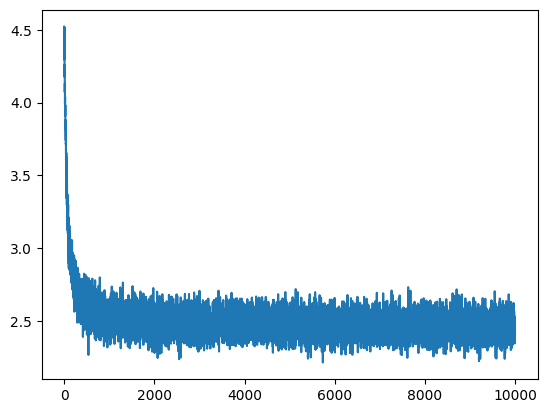

In [29]:
from matplotlib import pyplot as plt
plt.plot(every_train_losses)

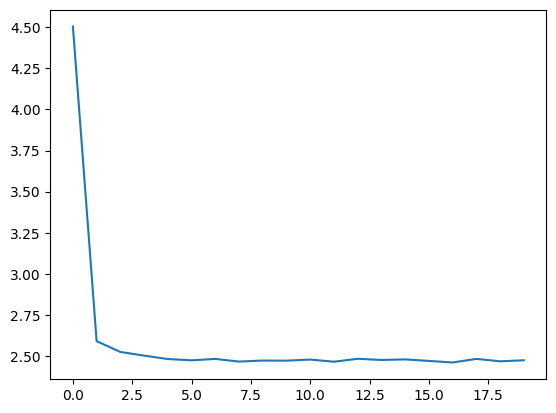

In [30]:
plt.plot(train_losses_eval_interval)

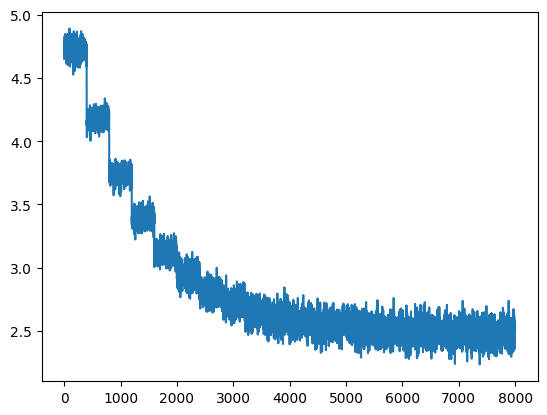

In [19]:
plt.plot(every_val_losses)

In [23]:
# @title
from IPython.display import HTML, Video

video_url = "https://lena-voita.github.io/resources/lectures/seq2seq/transformer/encoder_self_attention.mp4"
video_html = f"""
<video width="720" height="400" controls loop muted autoplay>
  <source src="{video_url}" type="video/mp4">
Your browser does not support the video tag.
</video>
"""

HTML(video_html)